<a href="https://colab.research.google.com/github/fankewe/ml-currency-volatility/blob/main/model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed


           Model           MSE      RMSE       MAE
0  Random Forest  1.075338e-07  0.000328  0.000193
1        XGBoost  1.119858e-07  0.000335  0.000229


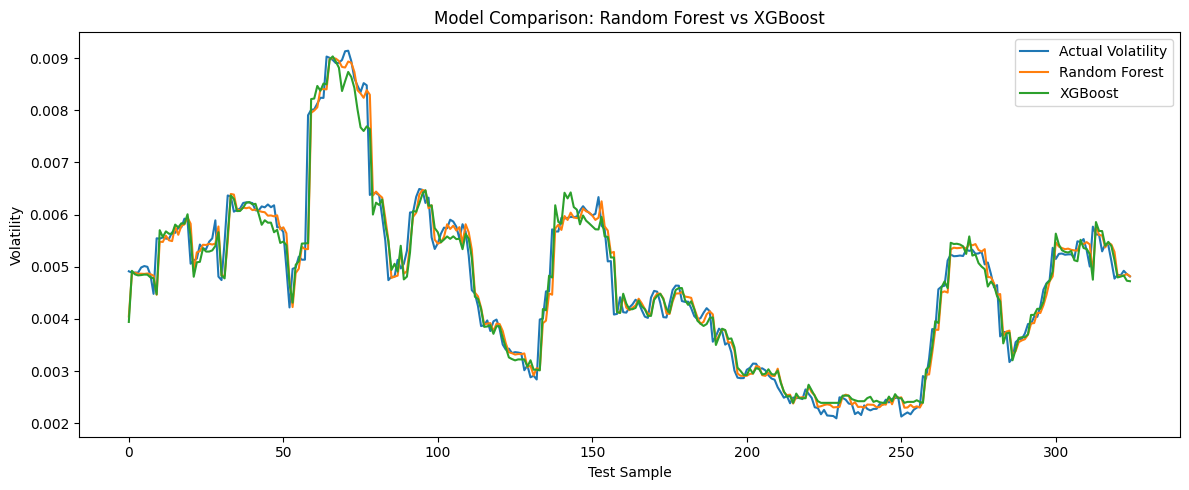

In [2]:
# ===================================
# Model Comparison: Random Forest vs XGBoost
# Currency Volatility Forecasting
# ===================================

# 1. Install XGBoost
!pip install xgboost -q

# 2. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 3. Download EUR/USD data
df = yf.download(
    "EURUSD=X",
    start="2020-01-01",
    auto_adjust=False
)

# 4. Fix yfinance MultiIndex columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 5. Preprocessing
df["price"] = df["Close"]
df["log_price"] = np.log(df["price"])
df["return"] = df["log_price"].diff()

# 6. Feature engineering
df["volatility_5"] = df["return"].rolling(5).std()
df["volatility_10"] = df["return"].rolling(10).std()
df["volatility_20"] = df["return"].rolling(20).std()

df["return_lag_1"] = df["return"].shift(1)
df["return_lag_2"] = df["return"].shift(2)
df["return_lag_3"] = df["return"].shift(3)
df["return_lag_5"] = df["return"].shift(5)

# 7. Target variable: next-period volatility
df["target_volatility"] = df["volatility_20"].shift(-1)

# 8. Drop missing values
df_model = df.dropna().copy()

# 9. Define X and y
features = [
    "return_lag_1",
    "return_lag_2",
    "return_lag_3",
    "return_lag_5",
    "volatility_5",
    "volatility_10",
    "volatility_20"
]

X = df_model[features]
y = df_model["target_volatility"]

# 10. Time-series train/test split
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# 11. Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 12. Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# 13. Evaluation metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MSE": [mse_rf, mse_xgb],
    "RMSE": [rmse_rf, rmse_xgb],
    "MAE": [mae_rf, mae_xgb]
})

print(comparison)

# 14. Plot: Actual vs RF vs XGBoost
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual Volatility")
plt.plot(y_pred_rf, label="Random Forest")
plt.plot(y_pred_xgb, label="XGBoost")

plt.title("Model Comparison: Random Forest vs XGBoost")
plt.xlabel("Test Sample")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()

plt.savefig("model_comparison_rf_xgboost.png", dpi=300)
plt.show()

# 15. Save comparison table
comparison.to_csv("model_comparison_metrics.csv", index=False)